In [1]:
# Code to test everything is working fine. 
import os 
import sys
sys.path.append("../../")


import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl
from torch.utils.data import DataLoader, Dataset

from vi_rnn.vae import VAE
from vi_rnn.train import train_VAE 
from vi_rnn.utils import *
from vi_rnn.evaluation import * 
from vi_rnn.saving import save_model, load_model
from vi_rnn.datasets import Basic_dataset

from py_rnn.model import RNN, predict
from py_rnn.train import train_rnn
from py_rnn.train import save_rnn, load_rnn
from py_rnn.default_params import get_default_params

import pandas as pd 

from sklearn.model_selection import train_test_split

from data.utils import * 

from evaluation.calc_stats import calc_isi_stats

%matplotlib inline

In [2]:
data_dir = '../../data/recordings/nk341_thalamus/' 
out_dir = "../../models/bla/" 

sampling_rate = 30_000 # khz
t_start, t_end = 0, 2700
bin_size = 0.02

neuromodulation = 'rank'

In [3]:
spikes = []

spikes_dir = os.path.join(data_dir, 'spikes')
for f in os.listdir(spikes_dir):
    spikes_df = pd.read_csv(f'{spikes_dir}/{f}', header=None)
    spikes.append(spikes_df.to_numpy().flatten() / sampling_rate)

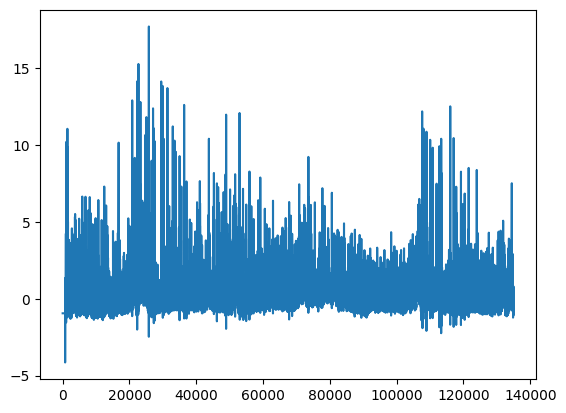

In [4]:
neuromod_dir = os.path.join(data_dir, 'neuromodulators')
lc_neuromod = pd.read_csv(f'{neuromod_dir}/norepinephrine.csv', header=None).to_numpy()

# replace nans with 0
lc_neuromod[np.isnan(lc_neuromod)] = 0.0

# bin the data 
slice_width = 20 
neuromod_trace = [np.mean(lc_neuromod[i:i + slice_width]) for i in range(0, len(lc_neuromod), slice_width)]
neuromod_trace = np.array(neuromod_trace)

neuromod_trace = (neuromod_trace - neuromod_trace.mean()) / neuromod_trace.std()
neuromod_trace = neuromod_trace[t_start * 50 : t_end * 50]
# plot the trace 
plt.plot(neuromod_trace)

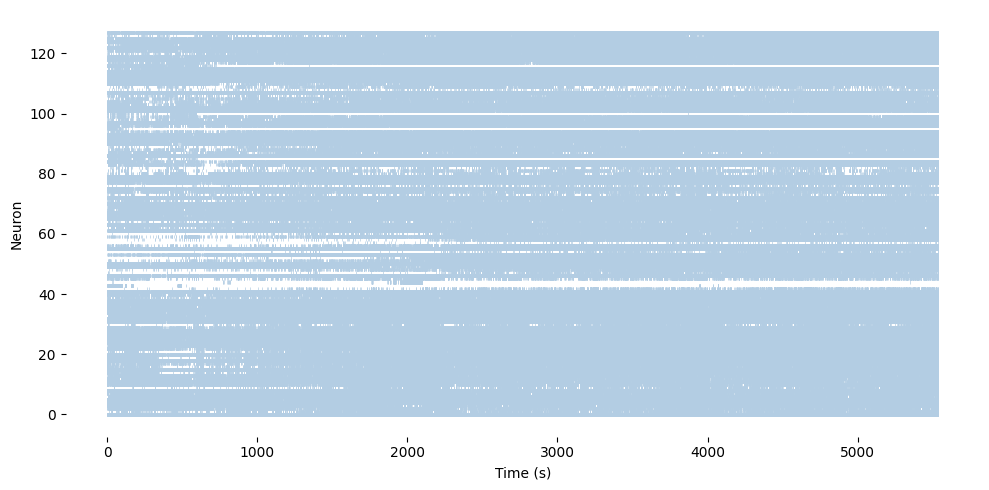

In [5]:
cmap = mpl.colormaps["Pastel1"]
color = cmap(1)
plt.figure(figsize=(10, 5))
plt.eventplot(spikes, linewidths=0.5, colors=color) 
plt.xlabel("Time (s)")
plt.ylabel("Neuron")

# convert x-axis from ms to s 
# ticks = plt.xticks()[0][1:-1]
# plt.xticks(ticks, labels=[f'{tick / 1000.0}' for tick in ticks]) 

# hide the right and top spines
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)
plt.tight_layout()

In [6]:
spike_counts = np.zeros((len(spikes), int((t_end - t_start) / bin_size)))
for i in range(len(spikes)):
    spike_counts[i], _ = bin_spike_train(spikes[i], t_start, t_end, bin_size)

In [7]:
total_counts = np.sum(spike_counts, axis=1)
rate = total_counts / (bin_size * len(total_counts))
threshold = 1000

idx = np.where(rate < threshold) 
print(f'Number of neurons with spike counts less than threshold: {len(idx[0])}')

spike_counts = np.delete(spike_counts, idx, axis=0)
print(f'Number of neurons in dataset: {spike_counts.shape[0]}')

# split into train and test samples 
dur = spike_counts.shape[1]
train_size = int(dur * 0.75)
print(f'Train sample size: {train_size}')
print(f'Test sample size: {dur - train_size}')

train_samples = spike_counts[:, :train_size]
test_samples = spike_counts[:, train_size:]

Number of neurons with spike counts less than threshold: 17
Number of neurons in dataset: 111
Train sample size: 101250
Test sample size: 33750


In [8]:
# initialise encoder
enc_params = {
    "first_layer": 24,
    "init_kernel_sizes": [24, 11, 1],
    "strides": [1, 1, 1],
    "padding_location": "causal",
    "padding_mode": "constant",
    "nonlinearity": "gelu",
    "dilations": [1, 1, 1],
    "n_channels": [128, 64],
    "n_hidden": 64,
    "init_scale": 0.1,
    "constant_var": False,
}

In [9]:
# initialise prior
rnn_params = {
    "clipped": True,
    "train_noise_x": True,  # False
    "train_noise_z": True,
    "train_noise_z_t0": True,
    "init_noise_z": 0.1,
    "init_noise_z_t0": 1,
    "init_noise_x": 0.1,
    "scalar_noise_z": False,
    "scalar_noise_x": False,
    "scalar_noise_z_t0": False,
    "identity_readout": True,
    "activation": "relu",
    "exp_par": True,
    "shared_tau": 0.9,
    "readout_rates": "currents",
    "train_obs_bias": True,
    "train_obs_weights": True,
    "train_latent_bias": False,
    "train_neuron_bias": True,
    "orth": False,
    "m_norm": False,
    "weight_dist": "uniform",
    "weight_scaler": 1,  # /dim_N,
    "initial_state": "trainable",
    "out_nonlinearity": "softplus",
    "neuromodulation": neuromodulation  
}

In [10]:
# initialise training parameters
training_params = {
    "smooth_at_eval": 200,
    "run_eval": False,
    "t_forward": 0,
    "lr": 1e-3,
    "step_size": 1, 
    "gamma": 0.99,
    "lr_end": 1e-6,
    "n_epochs": 200,
    "grad_norm": False,
    "eval_epochs": 10,
    "batch_size": 64,
    "cuda": False,
    "smoothing": 20,
    "freq_cut_off": 10000,
    "sim_obs_noise": 0,
    "sim_latent_noise": 1,
    "opt_eps": 1e-8,
    "grad_norm": 0,
    "sim_obs_noise": 0,
    "k": 64,
    "sim_v": False,
    "sim_s": False,
    "loss_f": "VGTF",
    "resample": "systematic",  # , multinomial or none"
    "observation_likelihood": "Poisson",  # observation likelihood,
    "neuromodulation": neuromodulation 
}

In [11]:
task_params = {
    "dur": 100,
    "n_trials": 3000,
    "name": "",
    "dataset_name": data_dir,
}

In [12]:
task = Basic_dataset(task_params, train_samples.T, s=neuromod_trace, data_eval=test_samples.T)

dim_x = task.data.shape[1]
dim_z = 3
dim_N = dim_x
dim_s = 1 

VAE_params = {
    "dim_x": dim_x,
    "dim_z": dim_z,
    "dim_N": dim_N,
    "dim_s": dim_s,
    "enc_architecture": "CNN",
    "enc_params": enc_params,
    "prior_architecture": "PLRNN",
    "rnn_params": rnn_params,
    "causal": True
}

In [13]:
vae = VAE(VAE_params)
train_VAE(vae, 
          training_params, 
          task, 
          sync_wandb=False, 
          out_dir=out_dir, 
          fname=f"thalamus_{neuromodulation}_LC_rank_{dim_z}_{dim_N}")

Neuromodulation type: rank
using clipped ReLU activation
using uniform init
weight scaler 1
using causal constant padding
Training on : cpu
Learning rate decay factor 0.9660508789898133
epoch 1 loss: 82.1475, ll: -82.1475, ll_x: 81.8921, ll_z: -2.9746 H: 4.0082, alpha: 0.37, lr: 0.001000, N_z: 0.0998, N_x: 0.1000
epoch 2 loss: 81.2970, ll: -81.2970, ll_x: 81.1366, ll_z: -2.8792 H: 3.6456, alpha: 0.30, lr: 0.000990, N_z: 0.0995, N_x: 0.1000
epoch 3 loss: 79.7413, ll: -79.7413, ll_x: 79.5486, ll_z: -2.7852 H: 3.5914, alpha: 0.24, lr: 0.000980, N_z: 0.0992, N_x: 0.1000
epoch 4 loss: 76.9008, ll: -76.9008, ll_x: 76.6411, ll_z: -2.5351 H: 3.5002, alpha: 0.22, lr: 0.000970, N_z: 0.0990, N_x: 0.1000
epoch 5 loss: 72.7843, ll: -72.7843, ll_x: 72.4936, ll_z: -2.4918 H: 3.4770, alpha: 0.22, lr: 0.000961, N_z: 0.0990, N_x: 0.1000
epoch 6 loss: 67.9428, ll: -67.9428, ll_x: 67.5877, ll_z: -2.4087 H: 3.4728, alpha: 0.22, lr: 0.000951, N_z: 0.0992, N_x: 0.1000
epoch 7 loss: 62.9911, ll: -62.9911, ll_

[]

In [13]:
vae, params, task_params, training_params = load_model('../../models/bla/thalamus_rank_LC_rank_4_120')

dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: rank
using clipped ReLU activation
using uniform init
weight scaler 1
using causal constant padding


c:\Users\kaleab.belay\Documents\Project\mnm\train_scripts\recordings\../..\vi_rnn\saving.py:152: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return lambda b: torch.load(io

In [14]:
T, dim_x = task.data_eval.shape
z_hat, _, _, _ = vae.encoder(task.data_eval[:T, :].T.unsqueeze(0))
z0 = z_hat[:, :, :1].squeeze() 
s_test = torch.from_numpy(neuromod_trace)[22500:].to(torch.float32).unsqueeze(0).unsqueeze(0)
Z = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, s=s_test, noise_scale=1, sim_v=False, sim_s=False)
# get spikes 
lmd = vae.rnn.get_observation(Z, noise_scale=0)[0, :, :, 0]
spikes_pred = torch.poisson(lmd).T.detach()

no input


Text(0.5, 1.0, 'Spikes from BLA')

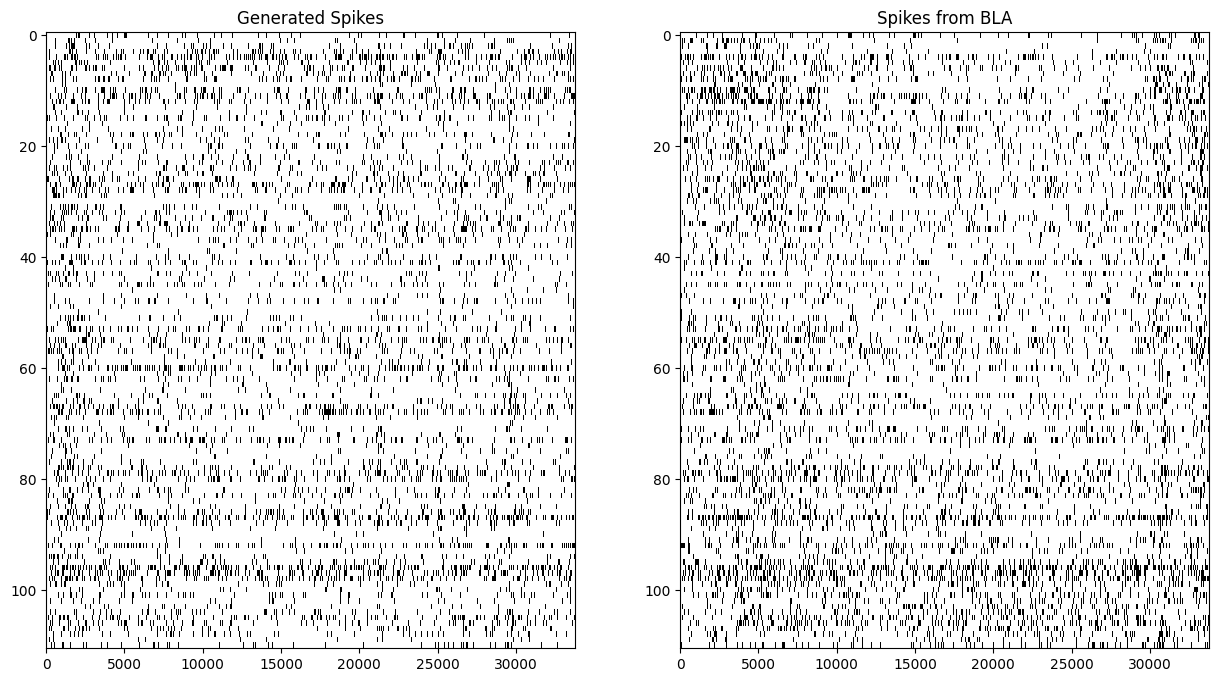

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(spikes_pred.T, aspect='auto', cmap='Greys', interpolation="none", vmax=1)
ax[1].imshow(task.data_eval[:T, :].T, aspect='auto', cmap='Greys', interpolation='none', vmax=1)

ax[0].set_title('Generated Spikes')
ax[1].set_title('Spikes from BLA')

In [16]:
CVs_isi_test, Means_isi_test, Std_isi_test = calc_isi_stats(task.data_eval[:T, :], dt=bin_size)
CVs_isi_gen, Means_isi_gen, Std_isi_gen = calc_isi_stats(spikes_pred, dt=bin_size)

Text(0.5, 1.0, 'Scatter plots of mean ISIs of test and generated samples')

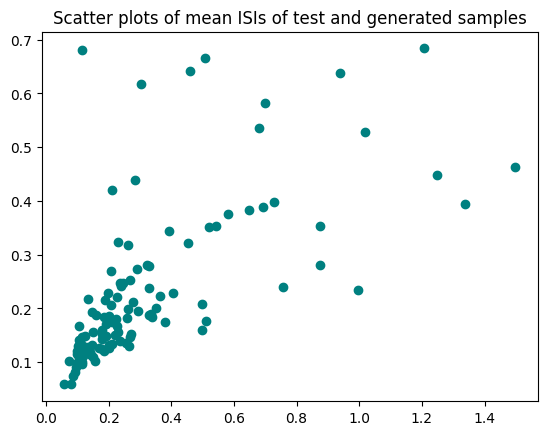

In [17]:
plt.scatter(Means_isi_gen, Means_isi_test, c='teal')
plt.title('Scatter plots of mean ISIs of test and generated samples')

Text(0.5, 1.0, 'Scatter plots of mean firing rates of test and generated samples')

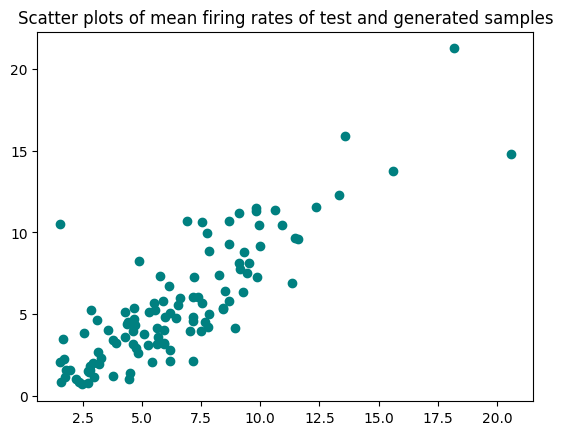

In [18]:
fr_test = torch.mean(task.data_eval[:T, :].T, axis=1) / bin_size
fr_gen = torch.mean(spikes_pred.T, axis=1) / bin_size 
plt.scatter(fr_test, fr_gen, c='teal')
plt.title('Scatter plots of mean firing rates of test and generated samples')

In [19]:
# Parameters
tau = 8  # Decay time constant

# Compute Van Rossum Distances 
vrds = np.zeros((spikes_pred.shape[1],))
for j in range(spikes_pred.shape[1]):
    vrd = van_rossum_distance(spikes_pred[:, j], task.data_eval[:, j], tau, T)
    vrds[j] = vrd 

In [22]:
np.mean(vrds), np.sum(vrds)

(21.182710217575565, 2351.2808341508876)

In [20]:
np.mean(vrds), np.sum(vrds)

(21.706209575641207, 2409.389262896174)

In [21]:
vae.rnn.transition.A

Parameter containing:
tensor([[-0.0228],
        [-0.1050],
        [-0.1684]], requires_grad=True)

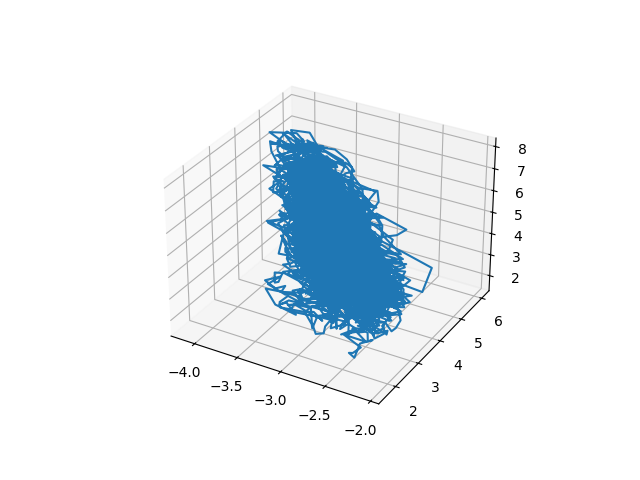

In [ ]:
%matplotlib ipympl
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(Z[0, 0, :, 0], Z[0, 1, :, 0], Z[0, 2, :, 0])

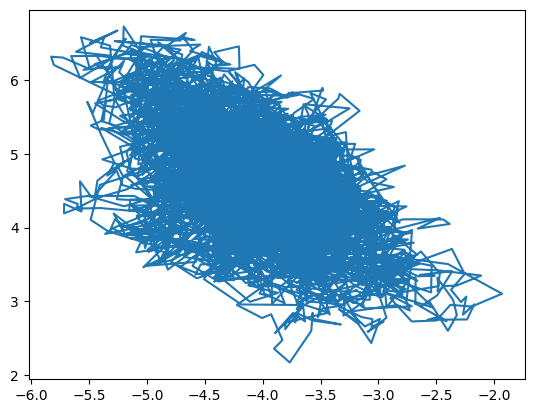

In [18]:
plt.plot(Z[0, 0, :, 0], Z[0, 1, :, 0])

In [20]:
from fixed_points.find_fixed_points_analytic import find_fixed_points_analytic

vae_orth = orthogonalise_network(vae)

# Get all fixed points of teacher RNN
tau, pV, pU, pB, pI = get_loadings(vae_orth)

# Get all fixed points of student RNN
D_list, D_inds, z_list, n_inverses = find_fixed_points_analytic(
    np.array([tau, tau, tau]), pV, pU, 0, pB
)

280840
8
(2246720, 120)
(288101, 120)
Found a fixed point
[2.66942222 0.31148129 1.60724624]
Found a fixed point
[1.05880587 1.33041705 1.52747559]
Done, found 2 fixed points


In [15]:
from fixed_points.find_fixed_points_analytic import find_fixed_points_analytic

vae_orth = orthogonalise_network(vae)

# Get all fixed points of teacher RNN
tau, pV, pU, pB, pI = get_loadings(vae_orth)

# Get all fixed points of student RNN
D_list, D_inds, z_list, n_inverses = find_fixed_points_analytic(
    np.array([tau]), pV, pU, 0, pB
)

120
2
(240, 120)
(121, 120)
Found a fixed point
[-34.90024948]
Done, found 1 fixed points
